In [16]:
# 1. Data Preprocessing

import pandas as pd

# Load dataset
data = pd.read_csv("sleep_health_og.csv")

# Replace spaces with underscore '_'
data.columns = data.columns.str.replace(' ', '_')
print(data.columns.tolist())

# Encode Gender: Male=0, Female=1
data['Gender'] = data['Gender'].map({'Male': 0, 'Female': 1})

#Encode Occuptation: Software Engineer=0, Doctor=1, Sales Representative=2, Teacher=3, Nurse=4, Engineer=5, Accountant=6, Scientist=7, Lawyer=8, Salesperson=9, Manager=10

data['Occupation'] = data['Occupation'].map({
    'Software Engineer': 0,
    'Doctor': 1,
    'Sales Representative': 2,
    'Teacher': 3,
    'Nurse': 4,
    'Engineer': 5,
    'Accountant': 6,
    'Scientist': 7,
    'Lawyer': 8,
    'Salesperson': 9,
    'Manager': 10
})

# Encode BMI_Category: Underweight=0, Normal=1, Overweight=2, Obese=3
data['BMI_Category'] = data['BMI_Category'].map({
    'Underweight': 0,
    'Normal': 1,
    'Normal Weight': 1,
    'Overweight': 2,
    'Obese': 3
})

# Encode Sleep_Disorder: None=0, Sleep Apnea=1, Insomnia=2
data['Sleep_Disorder'] = data['Sleep_Disorder'].map({
    'None': 0,
    'Sleep Apnea': 1,
    'Insomnia': 2
})

# Replace missing (null) values with the median of each column
data = data.fillna(data.median(numeric_only=True))

# Display cleaned data info

print(data.info()) #gives general info about the data

print(data.head(10))

print(data.iloc[:, :10]) # print the first 10 columns of the data frame

# After cleaning
data.columns = data.columns.str.strip().str.replace(' ', '_')
data.to_csv('sleep_health.csv', index=False)


['Person_ID', 'Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'BMI_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                374 non-null    int64  
 1   Gender                   374 non-null    int64  
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    int64  
 4   Sleep_Duration           374 non-null    float64
 5   Quality_of_Sleep         374 non-null    int64  
 6   Physical_Activity_Level  374 non-null    int64  
 7   Stress_Level             374 non-null    int64  
 8   BMI_Category             374 non-null    int64  
 9   Blood_Pressure           374 non-null    object 
 10  Heart_Rate               374 non-nu

In [5]:
# descriptive stats
import pandas as pd

# Load the dataset
data = pd.read_csv('sleep_health.csv')

# Generate a random sample of the data (size = 150)
sample_size = 150
ds = data.sample(n=sample_size, replace=False, random_state=42)

# Function to calculate descriptive statistics for 'Stress_Level' column
def Desc_stat(ds, Stress_Level):
    # Calculating various descriptive statistics for the Stress_Level column
    mean = ds[Stress_Level].mean()
    median = ds[Stress_Level].median()
    mode = ds[Stress_Level].mode()[0]  # mode() returns a series, so we select the first mode
    minimum = ds[Stress_Level].min()
    maximum = ds[Stress_Level].max()
    range_ = maximum - minimum
    std_dev = ds[Stress_Level].std()
    variance = ds[Stress_Level].var()
    skew = ds[Stress_Level].skew()
    kurtosis = ds[Stress_Level].kurt()
    count = ds[Stress_Level].count()

    # Quantiles and interquartile range (IQR)
    Quart = [
        ds[Stress_Level].quantile(0),
        ds[Stress_Level].quantile(0.25),
        ds[Stress_Level].quantile(0.50),
        ds[Stress_Level].quantile(0.75),
        ds[Stress_Level].quantile(1),
        ds[Stress_Level].quantile(0.75) - ds[Stress_Level].quantile(0.25)
    ]

    # Create a summary dictionary with all the statistics
    summary = {
        "Average": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": range_,
        "Standard Deviation": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "0th Percentile": Quart[0],
        "25th Percentile": Quart[1],
        "50th Percentile": Quart[2],
        "75th Percentile": Quart[3],
        "100th Percentile": Quart[4],
        "Interquartile Range (IQR)": Quart[5],
        "Count": count
    }
    return summary

Desc_stat(data, 'Stress_Level')


{'Average': np.float64(5.385026737967914),
 'Median': 5.0,
 'Mode': np.int64(3),
 'Minimum': 3,
 'Maximum': 8,
 'Range': 5,
 'Standard Deviation': 1.7745264441985167,
 'Variance': 3.1489441011598314,
 'Skewness': np.float64(0.15432958161578225),
 'Kurtosis': np.float64(-1.3273065644578361),
 '0th Percentile': np.float64(3.0),
 '25th Percentile': np.float64(4.0),
 '50th Percentile': np.float64(5.0),
 '75th Percentile': np.float64(7.0),
 '100th Percentile': np.float64(8.0),
 'Interquartile Range (IQR)': np.float64(3.0),
 'Count': np.int64(374)}

In [6]:
# desc stats for sleep duration - random sampling
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize

# Load the dataset
data = pd.read_csv('sleep_health.csv')

# Generate a random sample of the data
sample_size = 150
ds = data.sample(n=sample_size, replace=False, random_state=42)

# Function to calculate descriptive statistics for 'Sleep_Duration' column
def Desc_stat(ds, Sleep_Duration):
    # Calculating various descriptive statistics for the Sleep_Duration column
    mean = ds[Sleep_Duration].mean()
    median = ds[Sleep_Duration].median()
    mode = ds[Sleep_Duration].mode()[0]  # mode() returns a series, so we select the first mode
    minimum = ds[Sleep_Duration].min()
    maximum = ds[Sleep_Duration].max()
    range_ = maximum - minimum
    std_dev = ds[Sleep_Duration].std()
    variance = ds[Sleep_Duration].var()
    skew = ds[Sleep_Duration].skew()
    kurtosis = ds[Sleep_Duration].kurt()
    count = ds[Sleep_Duration].count()

    # Quantiles and interquartile range (IQR)
    Quart = [
        ds[Sleep_Duration].quantile(0),
        ds[Sleep_Duration].quantile(0.25),
        ds[Sleep_Duration].quantile(0.50),
        ds[Sleep_Duration].quantile(0.75),
        ds[Sleep_Duration].quantile(1),
        ds[Sleep_Duration].quantile(0.75) - ds[Sleep_Duration].quantile(0.25)
    ]

    # Create a summary dictionary with all the statistics
    summary = {
        "Average ": mean,
        "Median ": median,
        "Mode ": mode,
        "Minimum ": minimum,
        "Maximum ": maximum,
        "Range ": range_,
        "Standard Deviation ": std_dev,
        "Variance ": variance,
        "Skewness ": skew,
        "Kurtosis ": kurtosis,
        "0th Percentile ": Quart[0],
        "25th Percentile ": Quart[1],
        "50th Percentile ": Quart[2],
        "75th Percentile ": Quart[3],
        "100th Percentile ": Quart[4],
        "Interquartile Range (IQR) ": Quart[5],
        "Count ": count
    }

    return summary

# Call the function
Desc_stat(data, 'Sleep_Duration')



{'Average ': np.float64(7.132085561497325),
 'Median ': 7.2,
 'Mode ': np.float64(7.2),
 'Minimum ': 5.8,
 'Maximum ': 8.5,
 'Range ': 2.7,
 'Standard Deviation ': 0.7956567308898188,
 'Variance ': 0.6330696334102736,
 'Skewness ': np.float64(0.037554389846484834),
 'Kurtosis ': np.float64(-1.286506239045075),
 '0th Percentile ': np.float64(5.8),
 '25th Percentile ': np.float64(6.4),
 '50th Percentile ': np.float64(7.2),
 '75th Percentile ': np.float64(7.8),
 '100th Percentile ': np.float64(8.5),
 'Interquartile Range (IQR) ': np.float64(1.3999999999999995),
 'Count ': np.int64(374)}

In [7]:
# desc stats for quality of sleep - random sampling
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv('sleep_health.csv')

# Sample the data
sample_size = 150
ds = data.sample(n=sample_size, replace=False, random_state=42)

# Define function
def Desc_stat(ds, Quality_of_Sleep):
    mean = ds[Quality_of_Sleep].mean()
    median = ds[Quality_of_Sleep].median()
    mode = ds[Quality_of_Sleep].mode()[0]
    minimum = ds[Quality_of_Sleep].min()
    maximum = ds[Quality_of_Sleep].max()
    range_ = maximum - minimum
    std_dev = ds[Quality_of_Sleep].std()
    variance = ds[Quality_of_Sleep].var()
    skew = ds[Quality_of_Sleep].skew()
    kurtosis = ds[Quality_of_Sleep].kurt()
    count = ds[Quality_of_Sleep].count()

    Quart = [
        ds[Quality_of_Sleep].quantile(0),
        ds[Quality_of_Sleep].quantile(0.25),
        ds[Quality_of_Sleep].quantile(0.50),
        ds[Quality_of_Sleep].quantile(0.75),
        ds[Quality_of_Sleep].quantile(1),
        ds[Quality_of_Sleep].quantile(0.75) - ds[Quality_of_Sleep].quantile(0.25)
    ]

    summary = {
        "Average ": mean,
        "Median ": median,
        "Mode ": mode,
        "Minimum ": minimum,
        "Maximum ": maximum,
        "Range ": range_,
        "Standard Deviation ": std_dev,
        "Variance ": variance,
        "Skewness ": skew,
        "Kurtosis ": kurtosis,
        "0th Percentile ": Quart[0],
        "25th Percentile ": Quart[1],
        "50th Percentile ": Quart[2],
        "75th Percentile ": Quart[3],
        "100th Percentile ": Quart[4],
        "Interquartile Range (IQR) ": Quart[5],
        "Count ": count
    }

    return summary

# Run on the dataset
Desc_stat(data, 'Quality_of_Sleep')


{'Average ': np.float64(7.31283422459893),
 'Median ': 7.0,
 'Mode ': np.int64(8),
 'Minimum ': 4,
 'Maximum ': 9,
 'Range ': 5,
 'Standard Deviation ': 1.1969559197336044,
 'Variance ': 1.4327034737853186,
 'Skewness ': np.float64(-0.20744763173836073),
 'Kurtosis ': np.float64(-0.7482755418548042),
 '0th Percentile ': np.float64(4.0),
 '25th Percentile ': np.float64(6.0),
 '50th Percentile ': np.float64(7.0),
 '75th Percentile ': np.float64(8.0),
 '100th Percentile ': np.float64(9.0),
 'Interquartile Range (IQR) ': np.float64(2.0),
 'Count ': np.int64(374)}

In [8]:
# Systematic Sampling + Descriptive Statistics for Sleep_Duration

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from matplotlib.colors import Normalize

# Load and clean dataset
data = pd.read_csv('sleep_health.csv')
data.columns = data.columns.str.strip().str.replace(' ', '_')  # Clean column names

# Sample size
sample_size = 150

# Perform systematic sampling
def systematic_sampling(ds, sample_size):
    S = len(ds) // sample_size  # sampling interval
    start_index = random.randint(0, S - 1)
    sample_indices = list(range(start_index, len(ds), S))
    sample = ds.iloc[sample_indices]
    return sample

# Draw the sample
sample = systematic_sampling(data, sample_size)

# Function to calculate descriptive statistics for 'Sleep_Duration' column
def Desc_stat(ds, Sleep_Duration):
    mean = ds[Sleep_Duration].mean()
    median = ds[Sleep_Duration].median()
    mode = ds[Sleep_Duration].mode()[0]
    minimum = ds[Sleep_Duration].min()
    maximum = ds[Sleep_Duration].max()
    range_ = maximum - minimum
    std_dev = ds[Sleep_Duration].std()
    variance = ds[Sleep_Duration].var()
    skew = ds[Sleep_Duration].skew()
    kurtosis = ds[Sleep_Duration].kurt()
    count = ds[Sleep_Duration].count()

    Quart = [
        ds[Sleep_Duration].quantile(0),
        ds[Sleep_Duration].quantile(0.25),
        ds[Sleep_Duration].quantile(0.50),
        ds[Sleep_Duration].quantile(0.75),
        ds[Sleep_Duration].quantile(1),
        ds[Sleep_Duration].quantile(0.75) - ds[Sleep_Duration].quantile(0.25)
    ]

    summary = {
        "Average": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": range_,
        "Standard Deviation": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "0th Percentile": Quart[0],
        "25th Percentile": Quart[1],
        "50th Percentile": Quart[2],
        "75th Percentile": Quart[3],
        "100th Percentile": Quart[4],
        "Interquartile Range (IQR)": Quart[5],
        "Count": count
    }

    return summary

# Get summary
summary = Desc_stat(sample, 'Sleep_Duration')

# Print line by line
for stat, value in summary.items():
    print(f"{stat}: {round(value, 2)}")


Average: 7.14
Median: 7.2
Mode: 7.2
Minimum: 5.8
Maximum: 8.5
Range: 2.7
Standard Deviation: 0.78
Variance: 0.61
Skewness: 0.04
Kurtosis: -1.23
0th Percentile: 5.8
25th Percentile: 6.5
50th Percentile: 7.2
75th Percentile: 7.8
100th Percentile: 8.5
Interquartile Range (IQR): 1.3
Count: 187


In [9]:
# Systematic Sampling + Descriptive Statistics for quality of sleep
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from matplotlib.colors import Normalize

# Perform systematic sampling
def systematic_sampling(ds, sample_size):
    S = len(ds) // sample_size  # The interval between selected rows
    start_index = random.randint(0, S - 1)  # Random start
    sample_indices = list(range(start_index, len(ds), S))
    sample = ds.iloc[sample_indices]
    return sample

# Sample of 150 using systematic sampling
sample_size = 150
sample = systematic_sampling(data, sample_size)

# Function to calculate descriptive statistics for 'Quality_of_Sleep' column
def Desc_stat(ds, Quality_of_Sleep):
    mean = ds[Quality_of_Sleep].mean()
    median = ds[Quality_of_Sleep].median()
    mode = ds[Quality_of_Sleep].mode()[0]
    minimum = ds[Quality_of_Sleep].min()
    maximum = ds[Quality_of_Sleep].max()
    range_ = maximum - minimum
    std_dev = ds[Quality_of_Sleep].std()
    variance = ds[Quality_of_Sleep].var()
    skew = ds[Quality_of_Sleep].skew()
    kurtosis = ds[Quality_of_Sleep].kurt()
    count = ds[Quality_of_Sleep].count()
# Quantiles and interquartile range
    Quart = [
        ds[Quality_of_Sleep].quantile(0),
        ds[Quality_of_Sleep].quantile(0.25),
        ds[Quality_of_Sleep].quantile(0.50),
        ds[Quality_of_Sleep].quantile(0.75),
        ds[Quality_of_Sleep].quantile(1),
        ds[Quality_of_Sleep].quantile(0.75) - ds[Quality_of_Sleep].quantile(0.25)
    ]

    # Summary of statistics
    summary = {
        "Average": mean,
        "Median": median,
        "Mode": mode,
        "Minimum": minimum,
        "Maximum": maximum,
        "Range": range_,
        "Standard Deviation": std_dev,
        "Variance": variance,
        "Skewness": skew,
        "Kurtosis": kurtosis,
        "0th Percentile": Quart[0],
        "25th Percentile": Quart[1],
        "50th Percentile": Quart[2],
        "75th Percentile": Quart[3],
        "100th Percentile": Quart[4],
        "Interquartile Range (IQR)": Quart[5],
        "Count": count
    }

    return summary

# Get summary
summary = Desc_stat(sample, 'Quality_of_Sleep')

# Print line by line
for stat, value in summary.items():
    print(f"{stat}: {round(value, 2)}")



Average: 7.36
Median: 7.0
Mode: 8
Minimum: 4
Maximum: 9
Range: 5
Standard Deviation: 1.16
Variance: 1.35
Skewness: -0.25
Kurtosis: -0.69
0th Percentile: 4.0
25th Percentile: 6.0
50th Percentile: 7.0
75th Percentile: 8.0
100th Percentile: 9.0
Interquartile Range (IQR): 2.0
Count: 187


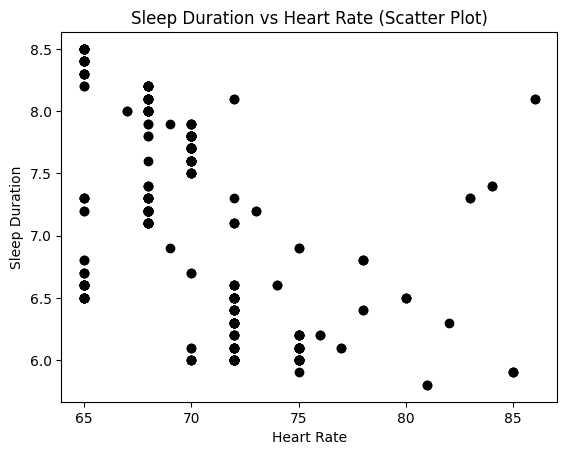

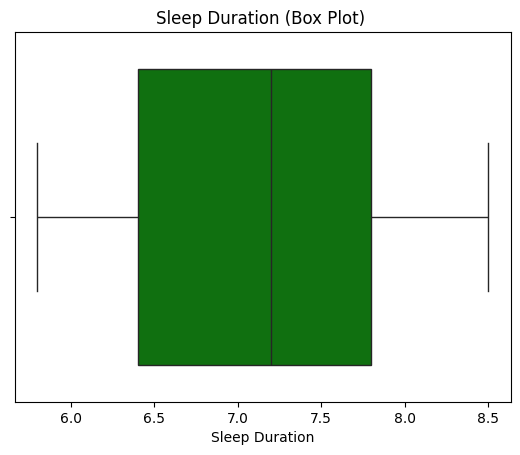

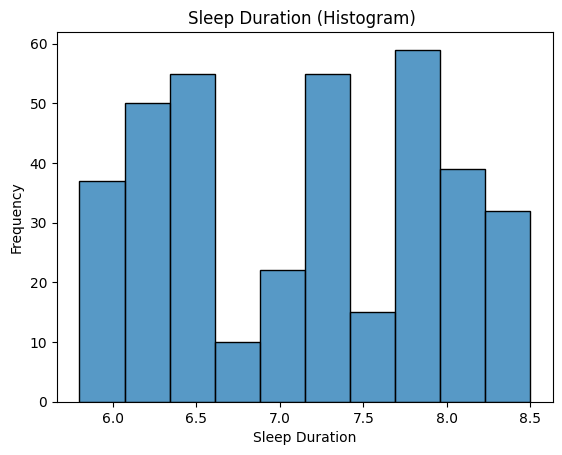

In [10]:
# graphs for sleep duration
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('sleep_health.csv')

# Scatter Plot (Sleep_Duration vs Heart Rate)
plt.scatter(data['Heart_Rate'], data['Sleep_Duration'], color='black')
plt.title('Sleep Duration vs Heart Rate (Scatter Plot)')
plt.xlabel('Heart Rate')
plt.ylabel('Sleep Duration')
plt.show()

# Box Plot for Sleep Duration
sns.boxplot(x=data['Sleep_Duration'], color='green')
plt.title('Sleep Duration (Box Plot) ')
plt.xlabel('Sleep Duration')
plt.show()

# Histogram for Sleep Duration
sns.histplot(data['Sleep_Duration'], bins=10, edgecolor='black')
plt.title('Sleep Duration (Histogram) ')
plt.xlabel('Sleep Duration')
plt.ylabel('Frequency')
plt.show()


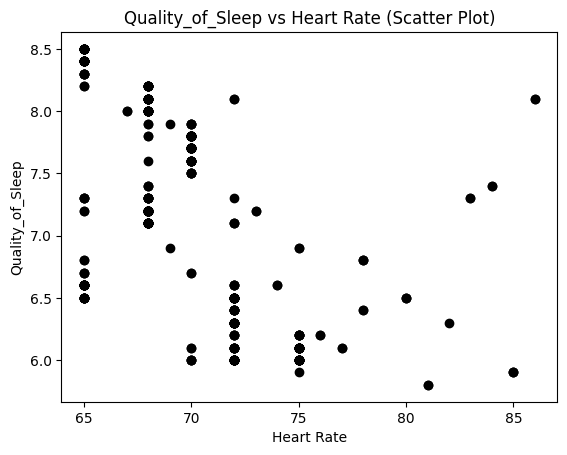

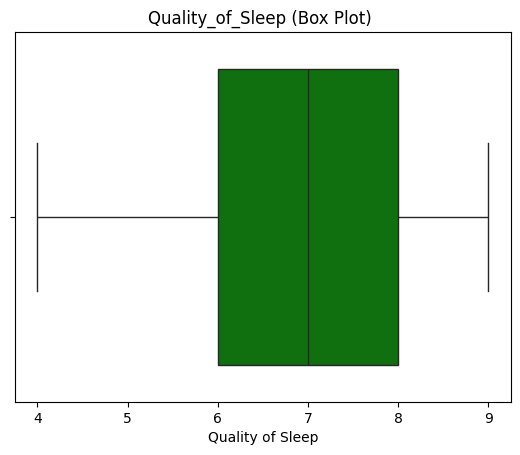

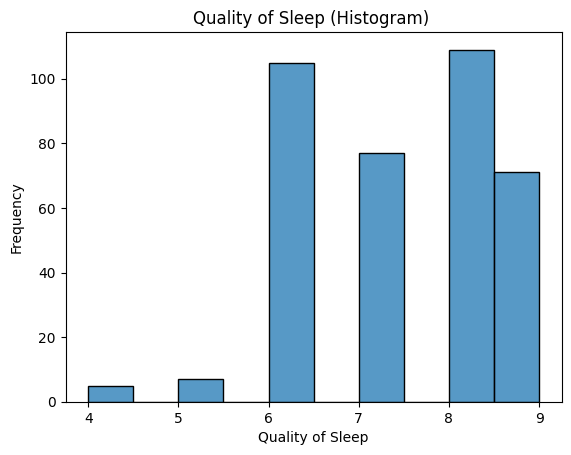

In [11]:
# graphs for quality of sleep
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_csv('sleep_health.csv')

# Scatter Plot (Quality_of_Sleep vs Heart Rate)
plt.scatter(data['Heart_Rate'], data['Sleep_Duration'], color='black')
plt.title('Quality_of_Sleep vs Heart Rate (Scatter Plot)')
plt.xlabel('Heart Rate')
plt.ylabel('Quality_of_Sleep')
plt.show()

# Box Plot for Quality of Sleep
sns.boxplot(x=data['Quality_of_Sleep'], color='green')
plt.title('Quality_of_Sleep (Box Plot) ')
plt.xlabel('Quality of Sleep')
plt.show()

# Histogram for Sleep Duration
sns.histplot(data['Quality_of_Sleep'], bins=10, edgecolor='black')
plt.title('Quality of Sleep (Histogram) ')
plt.xlabel('Quality of Sleep')
plt.ylabel('Frequency')
plt.show()




In [12]:
# Pearson and Spearman Correlation and Chi Square

# Importing the libraries
import pandas as pd
from scipy.stats import spearmanr
import scipy.stats as stats

# Load the dataset
data = pd.read_csv('sleep_health.csv')

#Correlation with Sleep duration
# Choose an independent numerical variable (Stress_Level) with Sleep Duration
numerical_var = 'Stress_Level'
dependent_var = 'Sleep_Duration'

# Perform Pearson Correlation
pearson_corr, pearson_p = stats.pearsonr(data[numerical_var], data[dependent_var])
print(f"Pearson Correlation (Stress Level vs. Sleep Duration): {pearson_corr}, P-value: {pearson_p}")

# Perform Spearman Correlation
spearman_corr, spearman_p = stats.spearmanr(data[numerical_var], data[dependent_var])
print(f"Spearman Correlation(Stress Level vs. Sleep Duration): {spearman_corr}, P-value: {spearman_p}")

# Correlation with Quality of Sleep
# Choose an independent numerical variable (Stress_Level) with Quality of Sleep
numerical_var1 = 'Stress_Level'
dependent_var1 = 'Quality_of_Sleep'

# Perform Pearson Correlation
pearson_corr, pearson_p = stats.pearsonr(data[numerical_var], data[dependent_var])
print(f"Pearson Correlation (Stress Level vs. Quality_of_Sleep): {pearson_corr}, P-value: {pearson_p}")

# Perform Spearman Correlation
spearman_corr, spearman_p = stats.spearmanr(data[numerical_var], data[dependent_var])
print(f"Spearman Correlation(Stress Level vs. Quality_of_Sleep): {spearman_corr}, P-value: {spearman_p}")

#Chi-Square test with sleep duration
# Choose an independent categorical variable (Occupation)
categorical_var = 'Occupation'
dependent_var = 'Sleep_Duration'

# Perform chi-square test for contigency table
contingency_table = pd.crosstab(data[categorical_var], data[dependent_var])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Statistic (Occupation vs. Sleep Duration): {chi2}, P-value: {chi_p}")

#Chi-Square test with sleep duration
# Choose an independent categorical variable (Occupation)
categorical_var = 'Occupation'
dependent_var1 = 'Quality_of_Sleep'

# Perform chi-square test for contigency table
contingency_table = pd.crosstab(data[categorical_var], data[dependent_var1])
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-square Statistic (Occupation vs. Quality of Sleep): {chi2}, P-value: {chi_p}")





Pearson Correlation (Stress Level vs. Sleep Duration): -0.8110230278940432, P-value: 1.2378076181537753e-88
Spearman Correlation(Stress Level vs. Sleep Duration): -0.8106325605674042, P-value: 1.746532119029682e-88
Pearson Correlation (Stress Level vs. Quality_of_Sleep): -0.8110230278940432, P-value: 1.2378076181537753e-88
Spearman Correlation(Stress Level vs. Quality_of_Sleep): -0.8106325605674042, P-value: 1.746532119029682e-88
Chi-square Statistic (Occupation vs. Sleep Duration): 1726.8212918833608, P-value: 1.4824855109827435e-214
Chi-square Statistic (Occupation vs. Quality of Sleep): 729.7082028686264, P-value: 1.8771307442285073e-121


In [13]:
# Sleep Duration t-test code
# Loading the dataset
data = pd.read_csv('sleep_health.csv')

# Dependent variable: Sleep Duration
Sleep_Duration = data['Sleep_Duration']

# recommended sleep duration
population_mean = 7  # Standard healthy sleep duration in hours

# Perform One-Sample t-Test
import scipy
t_stat, p_value = stats.ttest_1samp(Sleep_Duration, population_mean)

# Print results
print(f"One-Sample t-Test Results:")
print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

# Interpretation

if p_value < 0.05:
    print("Reject the null hypothesis: The sample mean significantly differs from the population mean.")
else:
    print("Fail to reject the null hypothesis: The sample mean is not significantly different from the population mean.")




One-Sample t-Test Results:
T-Statistic: 3.2104462758942
P-Value: 0.0014402421900475528
Reject the null hypothesis: The sample mean significantly differs from the population mean.


In [19]:
# Quality of Sleep t-test code
# Loading the dataset
data = pd.read_csv('sleep_health.csv')

# Dependent variable: Quality_of_Sleep
Quality_of_Sleep = data['Quality_of_Sleep']

# recommended Quality_of_Sleep
population_mean = 7.3  # Standard healthy quality of sleep

# Perform One-Sample t-Test
import scipy
t_stat, p_value = stats.ttest_1samp(Quality_of_Sleep, population_mean)

# Print results
print(f"One-Sample t-Test Results:")
print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

# Interpretation

if p_value < 0.05:
    print("Reject the null hypothesis: The sample mean significantly differs from the population mean.")
else:
    print("Fail to reject the null hypothesis: The sample mean is not significantly different from the population mean.")




One-Sample t-Test Results:
T-Statistic: 0.2073610958479127
P-Value: 0.8358410236919943
Fail to reject the null hypothesis: The sample mean is not significantly different from the population mean.


X (Stress Level): [[6]
 [8]
 [8]
 [8]
 [8]
 [8]
 [7]
 [6]
 [6]
 [6]
 [8]
 [6]
 [8]
 [8]
 [8]
 [8]
 [7]
 [8]
 [7]
 [6]]
y (Sleep Duration): [6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 6.1 7.8 6.1 6.  6.  6.  6.5 6.
 6.5 7.6]
MSE: 0.19262781765833684
R² Score: 0.7106694132038407


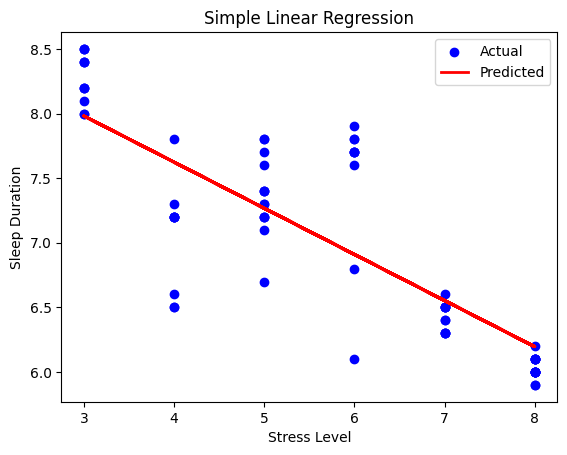

In [20]:
# simple linear regression for sleep duration
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data = pd.read_csv('sleep_health.csv')

# Select independent and dependent variables
X = data['Stress_Level'].values.reshape(-1, 1)
y = data['Sleep_Duration'].values

print("X (Stress Level):", X[:20])
print("y (Sleep Duration):", y[:20])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}")
print(f"R² Score: {r2}")

# Plot to compare model fit
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Duration')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()




X (Stress Level): [[6]
 [6]
 [6]
 [4]
 [4]
 [4]
 [6]
 [7]
 [7]
 [7]
 [6]
 [7]
 [6]
 [6]
 [6]
 [6]
 [5]
 [6]
 [5]
 [7]]
Y (Quality of Sleep): [6.1 6.2 6.2 5.9 5.9 5.9 6.3 7.8 7.8 7.8 6.1 7.8 6.1 6.  6.  6.  6.5 6.
 6.5 7.6]
MSE: 0.15332874175343036
R² Score: 0.7696973606225311


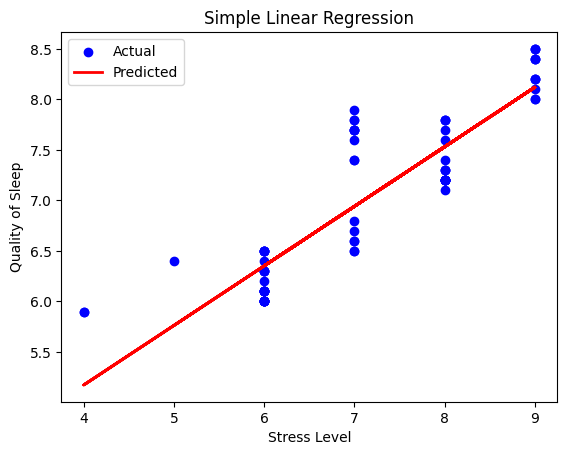

In [21]:
# simple linear regression for sleep duration
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
data = pd.read_csv('sleep_health.csv')

# Select independent and dependent variables
X = data['Quality_of_Sleep'].values.reshape(-1, 1)
y = data['Sleep_Duration'].values

print("X (Stress Level):", X[:20])
print("Y (Quality of Sleep):", y[:20])

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}")
print(f"R² Score: {r2}")

# Plot to compare model fit
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('Stress Level')
plt.ylabel('Quality of Sleep')
plt.title('Simple Linear Regression')
plt.legend()
plt.show()




In [22]:
# Python Code for both Sleep Duration and Quality of Sleep
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load and preprocess data
df = pd.read_csv("sleep_health.csv")

# Dependent variables
target_sleep_duration = df['Sleep_Duration']
target_quality_sleep = df['Quality_of_Sleep']

# Independent Variables
X = df[['Stress_Level', 'Physical_Activity_Level', 'Age']]

# Train-test split
X_train_sd, X_test_sd, y_train_sd, y_test_sd = train_test_split(X, target_sleep_duration, test_size=0.2, random_state=42)
X_train_qs, X_test_qs, y_train_qs, y_test_qs = train_test_split(X, target_quality_sleep, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and train models
model_sd = LinearRegression().fit(X_train_sd, y_train_sd)
model_qs = LinearRegression().fit(X_train_qs, y_train_qs)
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
pred_sd = model_sd.predict(X_test_sd)
pred_qs = model_qs.predict(X_test_qs)

# Output evaluation metrics
print("Sleep Duration Prediction")
print("MSE:", mean_squared_error(y_test_sd, pred_sd))
print("R² Score:", r2_score(y_test_sd, pred_sd))

print("Quality of Sleep Prediction")
print("MSE:", mean_squared_error(y_test_qs, pred_qs))
print("R² Score:", r2_score(y_test_qs, pred_qs))




Sleep Duration Prediction
MSE: 0.1703459825292916
R² Score: 0.7441371465310003
Quality of Sleep Prediction
MSE: 0.22207503663737158
R² Score: 0.8527961252551007


In [23]:
# Code for logistic regression on Sleep Duration and Quality of Sleep
# a. Importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# b. Importing the dataset
dataset = pd.read_csv('sleep_health.csv')

# Convert Sleep_Duration and Quality_of_Sleep into categorical classes
dataset['Sleep_Duration_Category'] = pd.cut(dataset['Sleep_Duration'],
                                            bins=[0, 6, 8, 24],
                                            labels=['Short', 'Normal', 'Long'])

dataset['Quality_of_Sleep_Category'] = pd.cut(dataset['Quality_of_Sleep'],
                                              bins=[0, 6, 8, 10],
                                              labels=['Poor', 'Good', 'Excellent'])

# Choose independent variables
X = dataset[['Gender', 'Age', 'Stress_Level', 'Physical_Activity_Level', 'BMI_Category', 'Heart_Rate', 'Daily_Steps']].values

# c. Encode the categorical dependent variable (Sleep Duration)
from sklearn.preprocessing import LabelEncoder
le_sleep = LabelEncoder()
y_sleep = le_sleep.fit_transform(dataset['Sleep_Duration_Category'])

# Encode the categorical dependent variable (Quality of Sleep)
le_quality = LabelEncoder()
y_quality = le_quality.fit_transform(dataset['Quality_of_Sleep_Category'])

# d. Splitting the dataset into the Training set and Test set (Sleep Duration)
from sklearn.model_selection import train_test_split
X_train_sd, X_test_sd, y_train_sd, y_test_sd = train_test_split(X, y_sleep, test_size=0.25, random_state=0)

# Splitting for Quality of Sleep
X_train_qs, X_test_qs, y_train_qs, y_test_qs = train_test_split(X, y_quality, test_size=0.25, random_state=0)

# e. Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_sd = sc.fit_transform(X_train_sd)
X_test_sd = sc.transform(X_test_sd)
X_train_qs = sc.fit_transform(X_train_qs)
X_test_qs = sc.transform(X_test_qs)

# f. Training the Logistic Regression model on Sleep Duration
from sklearn.linear_model import LogisticRegression
classifier_sd = LogisticRegression(random_state=0)
classifier_sd.fit(X_train_sd, y_train_sd)

# Training on Quality of Sleep
classifier_qs = LogisticRegression(random_state=0)
classifier_qs.fit(X_train_qs, y_train_qs)

# g. Making the Confusion Matrix and evaluating performance
from sklearn.metrics import confusion_matrix, accuracy_score

# Sleep Duration evaluation
y_pred_sd = classifier_sd.predict(X_test_sd)
cm_sd = confusion_matrix(y_test_sd, y_pred_sd)
print("Sleep Duration Confusion Matrix:\n", cm_sd)
print("Sleep Duration Accuracy:", accuracy_score(y_test_sd, y_pred_sd))

# Quality of Sleep evaluation
y_pred_qs = classifier_qs.predict(X_test_qs)
cm_qs = confusion_matrix(y_test_qs, y_pred_qs)
print("Quality of Sleep Confusion Matrix:\n", cm_qs)
print("Quality of Sleep Accuracy:", accuracy_score(y_test_qs, y_pred_qs))

# h. Predicting a new result
sample = [[0, 25, 5, 3, 1, 70, 800]]  # Example: Male, 25, stress 5, activity 3, BMI normal, heart rate 70, 800 steps
print("Predicted Sleep Duration Class:", le_sleep.inverse_transform(classifier_sd.predict(sc.transform(sample))))
print("Predicted Quality of Sleep Class:", le_quality.inverse_transform(classifier_qs.predict(sc.transform(sample))))




Sleep Duration Confusion Matrix:
 [[11  1  0]
 [ 2 66  2]
 [ 0  9  3]]
Sleep Duration Accuracy: 0.851063829787234
Quality of Sleep Confusion Matrix:
 [[14  1  0]
 [ 0 40  2]
 [ 0  2 35]]
Quality of Sleep Accuracy: 0.9468085106382979
Predicted Sleep Duration Class: ['Normal']
Predicted Quality of Sleep Class: ['Good']


In [24]:
# KNN for Sleep Duration and Quality of Sleep
# Step A: Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Step B: Load the dataset
dataset = pd.read_csv('sleep_health.csv')

# Convert Sleep_Duration and Quality_of_Sleep into categories
dataset['Sleep_Duration_Category'] = pd.cut(dataset['Sleep_Duration'],
                                            bins=[0, 6, 8, 24],
                                            labels=['Short', 'Normal', 'Long'])

dataset['Quality_of_Sleep_Category'] = pd.cut(dataset['Quality_of_Sleep'],
                                              bins=[0, 6, 8, 10],
                                              labels=['Poor', 'Good', 'Excellent'])

# Select features
X = dataset[['Gender', 'Age', 'Stress_Level', 'Physical_Activity_Level', 'BMI_Category', 'Heart_Rate', 'Daily_Steps']].values

# Encode Sleep Duration target
le_sleep = LabelEncoder()
y_sleep = le_sleep.fit_transform(dataset['Sleep_Duration_Category'])

# Encode Quality of Sleep target
le_quality = LabelEncoder()
y_quality = le_quality.fit_transform(dataset['Quality_of_Sleep_Category'])

# Step C: Split the dataset
X_train_sd, X_test_sd, y_train_sd, y_test_sd = train_test_split(X, y_sleep, test_size=0.25, random_state=0)
X_train_qs, X_test_qs, y_train_qs, y_test_qs = train_test_split(X, y_quality, test_size=0.25, random_state=0)

# Step D: Feature Scaling
sc_sd = StandardScaler()
X_train_sd = sc_sd.fit_transform(X_train_sd)
X_test_sd = sc_sd.transform(X_test_sd)

sc_qs = StandardScaler()
X_train_qs = sc_qs.fit_transform(X_train_qs)
X_test_qs = sc_qs.transform(X_test_qs)

# Step E: Train the KNN model (Sleep Duration)
classifier_sd = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier_sd.fit(X_train_sd, y_train_sd)

# Train the KNN model (Quality of Sleep)
classifier_qs = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
classifier_qs.fit(X_train_qs, y_train_qs)

# Step F: Predict on the test set
y_pred_sd = classifier_sd.predict(X_test_sd)
y_pred_qs = classifier_qs.predict(X_test_qs)

# Step G: Evaluate model performance
cm_sd = confusion_matrix(y_test_sd, y_pred_sd)
acc_sd = accuracy_score(y_test_sd, y_pred_sd)

cm_qs = confusion_matrix(y_test_qs, y_pred_qs)
acc_qs = accuracy_score(y_test_qs, y_pred_qs)

# Display confusion matrix and accuracy
print("Sleep Duration Confusion Matrix:")
print(cm_sd)
print("\nSleep Duration Accuracy: {:.2f}%".format(acc_sd * 100))

print("\nQuality of Sleep Confusion Matrix:")
print(cm_qs)
print("\nQuality of Sleep Accuracy: {:.2f}%".format(acc_qs * 100))

# Step H: Predict a new sample (example values)
# Example: Male, 25, Stress 5, Activity 3, BMI Normal, Heart Rate 70, Steps 800
new_sample = [[0, 25, 5, 3, 1, 70, 800]]

# Predict Sleep Duration
new_sample_scaled_sd = sc_sd.transform(new_sample)
predicted_sd_class = classifier_sd.predict(new_sample_scaled_sd)
print("\nPredicted Sleep Duration Class:", le_sleep.inverse_transform(predicted_sd_class)[0])

# Predict Quality of Sleep
new_sample_scaled_qs = sc_qs.transform(new_sample)
predicted_qs_class = classifier_qs.predict(new_sample_scaled_qs)
print("Predicted Quality of Sleep Class:", le_quality.inverse_transform(predicted_qs_class)[0])




Sleep Duration Confusion Matrix:
[[11  1  0]
 [ 1 65  4]
 [ 0  4  8]]

Sleep Duration Accuracy: 89.36%

Quality of Sleep Confusion Matrix:
[[13  2  0]
 [ 0 40  2]
 [ 0  1 36]]

Quality of Sleep Accuracy: 94.68%

Predicted Sleep Duration Class: Normal
Predicted Quality of Sleep Class: Poor


In [25]:
# Naïve Bayes for Sleep Duration and Quality of Sleep
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# Step 2: Load the dataset
df = pd.read_csv("sleep_health.csv")

# Step 3: Prepare target classes
# Convert Sleep Duration and Quality of Sleep into categories
df['Sleep_Duration_Category'] = pd.cut(df['Sleep_Duration'], bins=[0, 6, 8, 24], labels=['Short', 'Normal', 'Long'])
df['Quality_of_Sleep_Category'] = pd.cut(df['Quality_of_Sleep'], bins=[0, 6, 8, 10], labels=['Poor', 'Good', 'Excellent'])

# Select independent features
X = df[['Gender', 'Age', 'Stress_Level', 'Physical_Activity_Level', 'BMI_Category', 'Heart_Rate', 'Daily_Steps']].values

# Encode target for Sleep Duration
le_sleep = LabelEncoder()
y_sleep = le_sleep.fit_transform(df['Sleep_Duration_Category'])

# Encode target for Quality of Sleep
le_quality = LabelEncoder()
y_quality = le_quality.fit_transform(df['Quality_of_Sleep_Category'])

# Step 4: Split dataset (80-20 split)
X_train_sd, X_test_sd, y_train_sd, y_test_sd = train_test_split(X, y_sleep, test_size=0.2, random_state=0)
X_train_qs, X_test_qs, y_train_qs, y_test_qs = train_test_split(X, y_quality, test_size=0.2, random_state=0)

# Step 5: Feature Scaling
sc_sd = StandardScaler()
X_train_sd = sc_sd.fit_transform(X_train_sd)
X_test_sd = sc_sd.transform(X_test_sd)

sc_qs = StandardScaler()
X_train_qs = sc_qs.fit_transform(X_train_qs)
X_test_qs = sc_qs.transform(X_test_qs)

# Step 6: Train the Naive Bayes classifier (Sleep Duration)
classifier_sd = GaussianNB()
classifier_sd.fit(X_train_sd, y_train_sd)

# Train the Naive Bayes classifier (Quality of Sleep)
classifier_qs = GaussianNB()
classifier_qs.fit(X_train_qs, y_train_qs)

# Step 7: Predict on the test set
y_pred_sd = classifier_sd.predict(X_test_sd)
y_pred_qs = classifier_qs.predict(X_test_qs)

# Step 8: Evaluate the model
cm_sd = confusion_matrix(y_test_sd, y_pred_sd)
accuracy_sd = accuracy_score(y_test_sd, y_pred_sd)

cm_qs = confusion_matrix(y_test_qs, y_pred_qs)
accuracy_qs = accuracy_score(y_test_qs, y_pred_qs)

# Display results
print("Sleep Duration Confusion Matrix:\n", cm_sd)
print("Sleep Duration Accuracy:", accuracy_sd)

print("\nQuality of Sleep Confusion Matrix:\n", cm_qs)
print("Quality of Sleep Accuracy:", accuracy_qs)

# Step 9: Predict a new sample (example values)
sample = [[0, 25, 5, 3, 1, 70, 800]]  # Example: Male, 25, Stress 5, Activity 3, BMI Normal, HR 70, Steps 800

# Predict for Sleep Duration
sample_scaled_sd = sc_sd.transform(sample)
prediction_sd = classifier_sd.predict(sample_scaled_sd)
print("\nPredicted Sleep Duration Class:", le_sleep.inverse_transform(prediction_sd)[0])

# Predict for Quality of Sleep
sample_scaled_qs = sc_qs.transform(sample)
prediction_qs = classifier_qs.predict(sample_scaled_qs)
print("Predicted Quality of Sleep Class:", le_quality.inverse_transform(prediction_qs)[0])




Sleep Duration Confusion Matrix:
 [[ 8  1  0]
 [ 2 46  8]
 [ 0  0 10]]
Sleep Duration Accuracy: 0.8533333333333334

Quality of Sleep Confusion Matrix:
 [[10  1  0]
 [ 0 31  4]
 [ 0  0 29]]
Quality of Sleep Accuracy: 0.9333333333333333

Predicted Sleep Duration Class: Normal
Predicted Quality of Sleep Class: Poor


In [26]:
# Decision Tree for Sleep Duration and Quality of Sleep
# Step 1: Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score

# Step 2: Load the dataset
dataset = pd.read_csv('sleep_health.csv')

# Step 3: Prepare target classes
# Convert Sleep Duration and Quality of Sleep into categories
dataset['Sleep_Duration_Category'] = pd.cut(dataset['Sleep_Duration'], bins=[0, 6, 8, 24], labels=['Short', 'Normal', 'Long'])
dataset['Quality_of_Sleep_Category'] = pd.cut(dataset['Quality_of_Sleep'], bins=[0, 6, 8, 10], labels=['Poor', 'Good', 'Excellent'])

# Select independent features
X = dataset[['Gender', 'Age', 'Stress_Level', 'Physical_Activity_Level', 'BMI_Category', 'Heart_Rate', 'Daily_Steps']].values

# Encode Sleep Duration target
le_sleep = LabelEncoder()
y_sleep = le_sleep.fit_transform(dataset['Sleep_Duration_Category'])

# Encode Quality of Sleep target
le_quality = LabelEncoder()
y_quality = le_quality.fit_transform(dataset['Quality_of_Sleep_Category'])

# Step 4: Split the data (75-25 split)
X_train_sd, X_test_sd, y_train_sd, y_test_sd = train_test_split(X, y_sleep, test_size=0.25, random_state=0)
X_train_qs, X_test_qs, y_train_qs, y_test_qs = train_test_split(X, y_quality, test_size=0.25, random_state=0)

# Step 5: Feature Scaling
sc_sd = StandardScaler()
X_train_sd = sc_sd.fit_transform(X_train_sd)
X_test_sd = sc_sd.transform(X_test_sd)

sc_qs = StandardScaler()
X_train_qs = sc_qs.fit_transform(X_train_qs)
X_test_qs = sc_qs.transform(X_test_qs)

# Step 6: Train the Decision Tree model (Sleep Duration)
classifier_sd = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier_sd.fit(X_train_sd, y_train_sd)

# Train the Decision Tree model (Quality of Sleep)
classifier_qs = DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier_qs.fit(X_train_qs, y_train_qs)

# Step 7: Make predictions
y_pred_sd = classifier_sd.predict(X_test_sd)
y_pred_qs = classifier_qs.predict(X_test_qs)

# Step 8: Evaluate using confusion matrix and accuracy
cm_sd = confusion_matrix(y_test_sd, y_pred_sd)
accuracy_sd = accuracy_score(y_test_sd, y_pred_sd)
print("Sleep Duration Confusion Matrix:\n", cm_sd)
print("Sleep Duration Accuracy Score:", accuracy_sd)

cm_qs = confusion_matrix(y_test_qs, y_pred_qs)
accuracy_qs = accuracy_score(y_test_qs, y_pred_qs)
print("\nQuality of Sleep Confusion Matrix:\n", cm_qs)
print("Quality of Sleep Accuracy Score:", accuracy_qs)

# Step 9: Predicting a new sample
# Example input (Male, 25, Stress 5, Activity 3, BMI Normal, HR 70, Steps 800)
new_sample = [[0, 25, 5, 3, 1, 70, 800]]

# Predict Sleep Duration
new_sample_scaled_sd = sc_sd.transform(new_sample)
prediction_sd = classifier_sd.predict(new_sample_scaled_sd)
print("\nPredicted Sleep Duration Class:", le_sleep.inverse_transform(prediction_sd)[0])

# Predict Quality of Sleep
new_sample_scaled_qs = sc_qs.transform(new_sample)
prediction_qs = classifier_qs.predict(new_sample_scaled_qs)
print("Predicted Quality of Sleep Class:", le_quality.inverse_transform(prediction_qs)[0])




Sleep Duration Confusion Matrix:
 [[12  0  0]
 [ 1 65  4]
 [ 0  3  9]]
Sleep Duration Accuracy Score: 0.9148936170212766

Quality of Sleep Confusion Matrix:
 [[15  0  0]
 [ 0 42  0]
 [ 0  0 37]]
Quality of Sleep Accuracy Score: 1.0

Predicted Sleep Duration Class: Normal
Predicted Quality of Sleep Class: Good



=== Sleep Duration ===
Logistic Regression Accuracy: 0.8404
Logistic Regression Confusion Matrix:
[[15  0  0]
 [ 2 64  0]
 [ 0 13  0]]



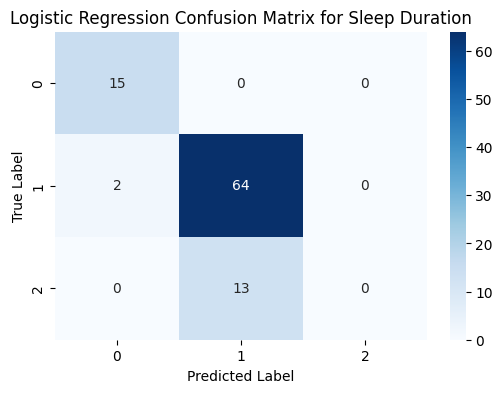

KNN Accuracy: 0.8723
KNN Confusion Matrix:
[[11  4  0]
 [ 0 64  2]
 [ 0  6  7]]



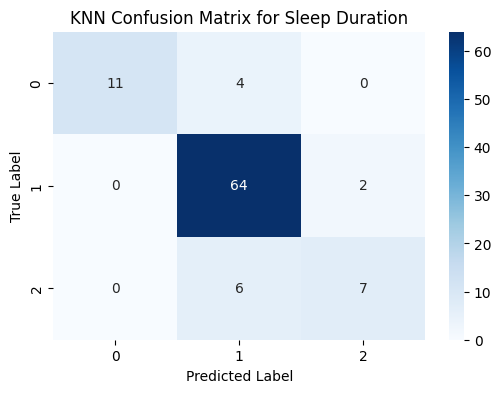

Naive Bayes Accuracy: 0.8936
Naive Bayes Confusion Matrix:
[[15  0  0]
 [ 2 56  8]
 [ 0  0 13]]



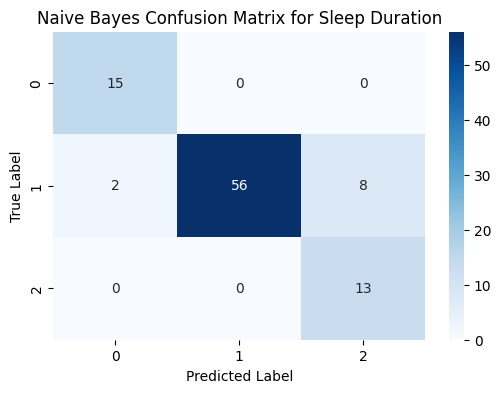

Decision Tree Accuracy: 0.9255
Decision Tree Confusion Matrix:
[[15  0  0]
 [ 1 59  6]
 [ 0  0 13]]



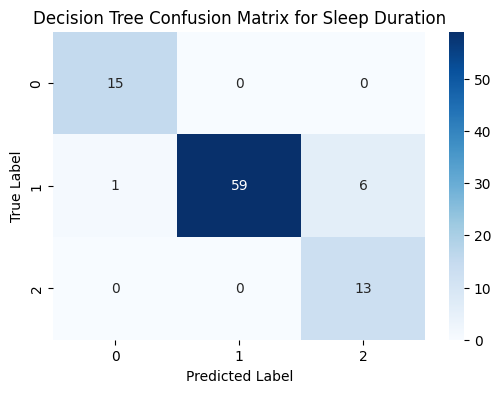

Best Model for Sleep Duration: DecisionTreeClassifier with Accuracy: 0.9255

=== Quality of Sleep ===
Logistic Regression Accuracy: 0.9787
Logistic Regression Confusion Matrix:
[[17  0  0]
 [ 0 40  2]
 [ 0  0 35]]



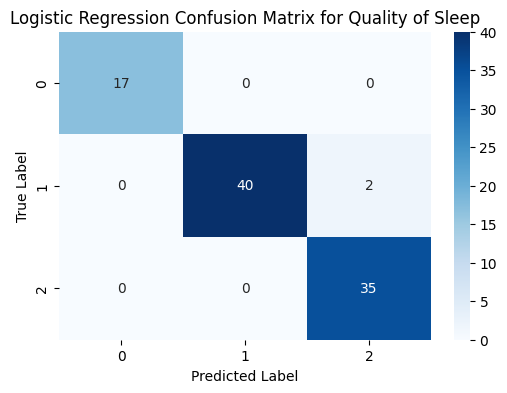

KNN Accuracy: 0.9787
KNN Confusion Matrix:
[[17  0  0]
 [ 1 40  1]
 [ 0  0 35]]



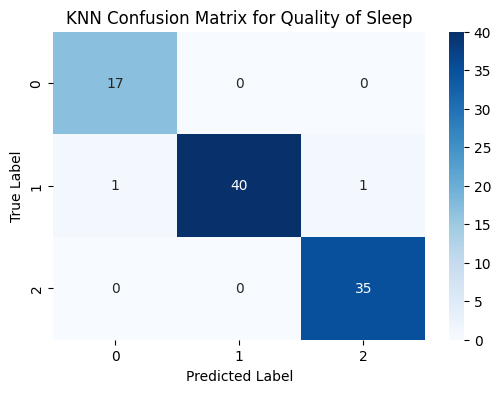

Naive Bayes Accuracy: 0.9681
Naive Bayes Confusion Matrix:
[[17  0  0]
 [ 0 39  3]
 [ 0  0 35]]



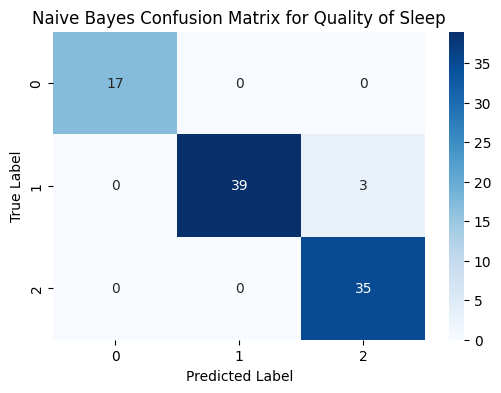

Decision Tree Accuracy: 0.9787
Decision Tree Confusion Matrix:
[[17  0  0]
 [ 0 40  2]
 [ 0  0 35]]



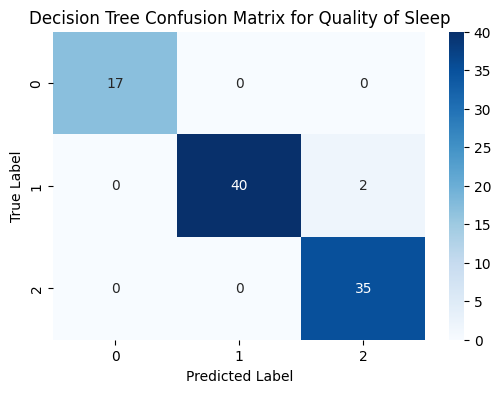

Best Model for Quality of Sleep: LogisticRegression with Accuracy: 0.9787


In [27]:
# Best fit Classifier code:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('sleep_health.csv')

# Preprocess features
df['Sleep_Duration_Category'] = pd.cut(df['Sleep_Duration'], bins=[0,6,8,24], labels=['Short','Normal','Long'])
df['Quality_of_Sleep_Category'] = pd.cut(df['Quality_of_Sleep'], bins=[0,6,8,10], labels=['Poor','Good','Excellent'])
X = df[['Gender','Age','Stress_Level','Physical_Activity_Level','BMI_Category','Heart_Rate','Daily_Steps']].values

# Encode targets
le = LabelEncoder()
targets = {
    "Sleep Duration": le.fit_transform(df['Sleep_Duration_Category']),
    "Quality of Sleep": le.fit_transform(df['Quality_of_Sleep_Category'])
}

# Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier()
}

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Run loop for both targets
for target_name, y in targets.items():
    print(f"\n=== {target_name} ===")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
    best_model = None
    best_acc = 0

    for name, clf in classifiers.items():
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        print(f"{name} Accuracy: {acc:.4f}")

        cm = confusion_matrix(y_test, y_pred)
        print(f"{name} Confusion Matrix:\n{cm}\n")

        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.title(f"{name} Confusion Matrix for {target_name}")
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")
        plt.show()

        if acc > best_acc:
            best_acc = acc
            best_model = clf

    print(f"Best Model for {target_name}: {best_model.__class__.__name__} with Accuracy: {best_acc:.4f}")





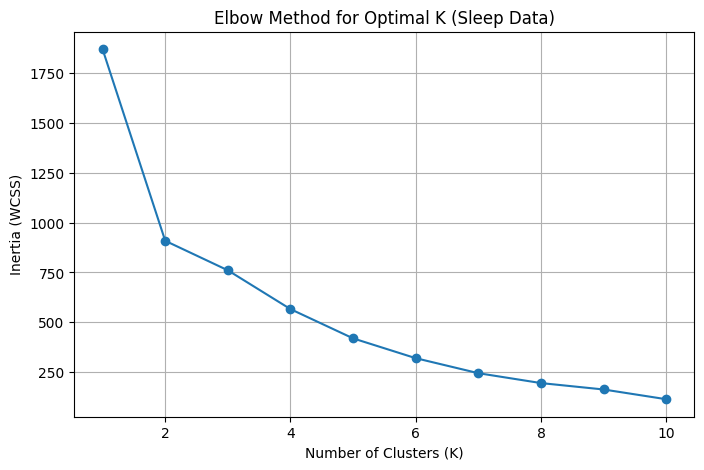

Chosen number of clusters (k): 3


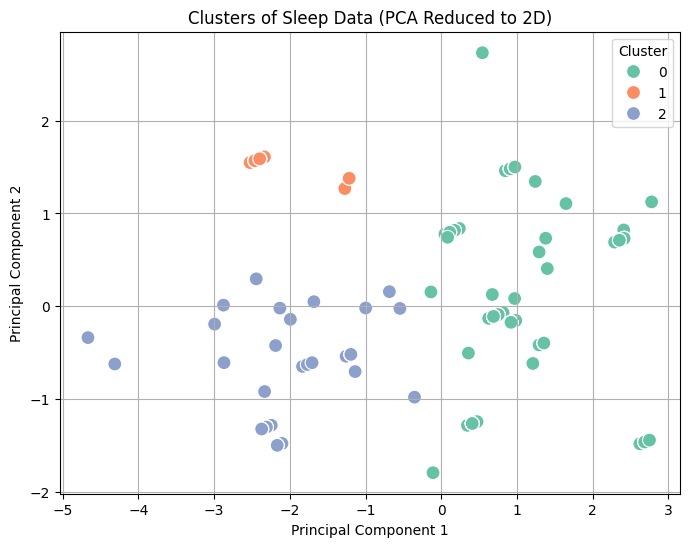

In [28]:
# K-means Code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Load the sleep dataset
data = pd.read_csv("sleep_health.csv")

# Step 2: Preprocess the data
# Select numeric features to cluster on
features = data[['Sleep_Duration', 'Quality_of_Sleep', 'Stress_Level', 'Physical_Activity_Level', 'Heart_Rate']].copy()
features.fillna(features.mean(), inplace=True)  # Handle missing values

# Step 3: Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Step 4: Determine optimal k using the Elbow Method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K (Sleep Data)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)
plt.show()

# Step 5: Apply KMeans
k = 3  # You can adjust this after elbow plot
print(f"Chosen number of clusters (k): {k}")
kmeans = KMeans(n_clusters=k, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_features)
data['Cluster'] = cluster_labels

# Step 6: PCA for 2D Visualization
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)
data['PCA1'] = pca_components[:, 0]
data['PCA2'] = pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=data, palette='Set2', s=100)
plt.title("Clusters of Sleep Data (PCA Reduced to 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Cluster')
plt.grid(True)
plt.show()



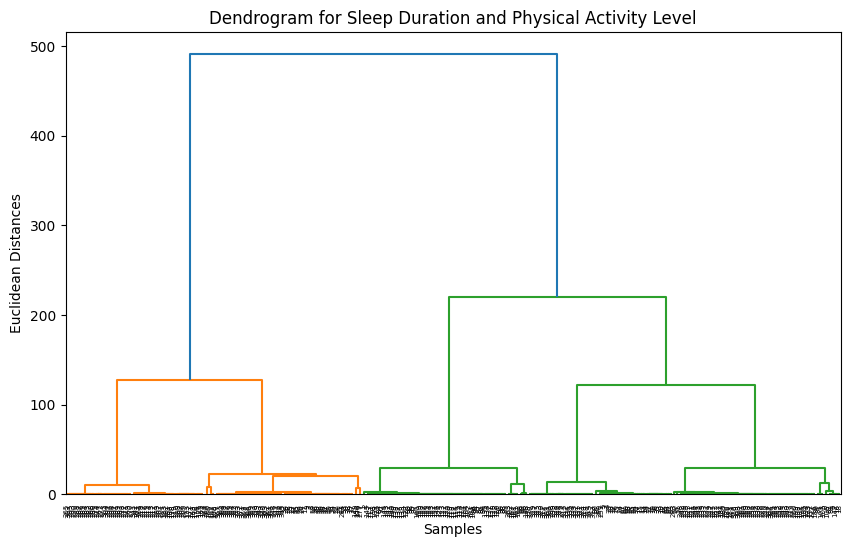

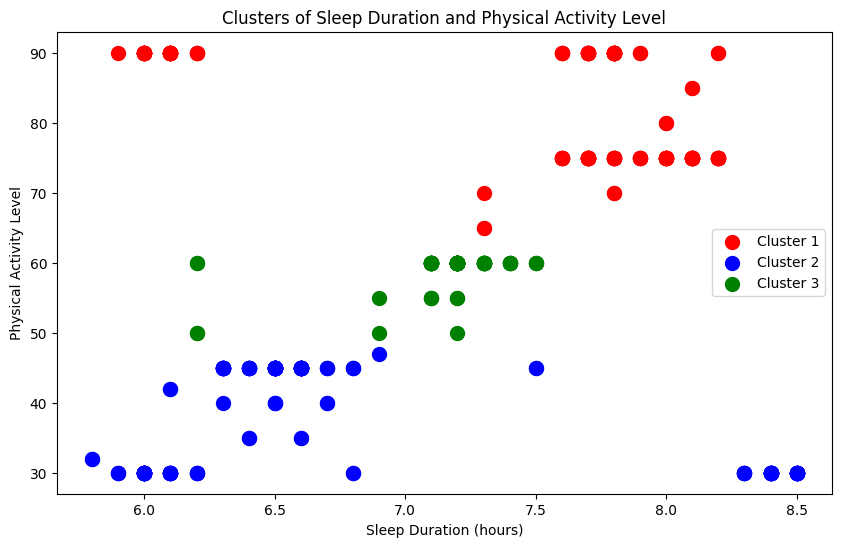

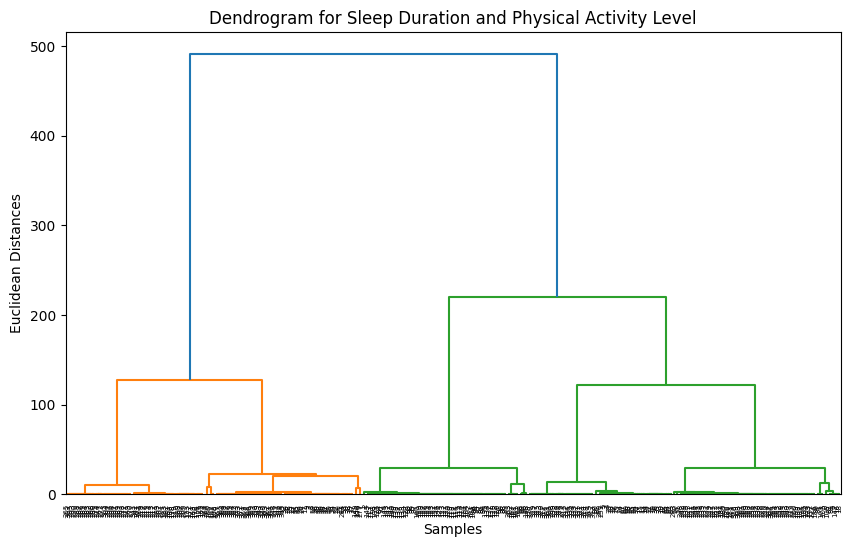

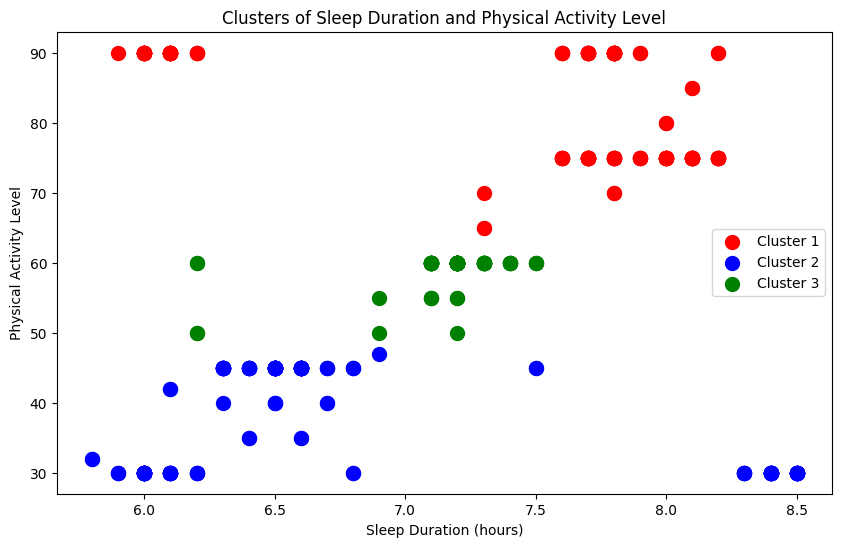

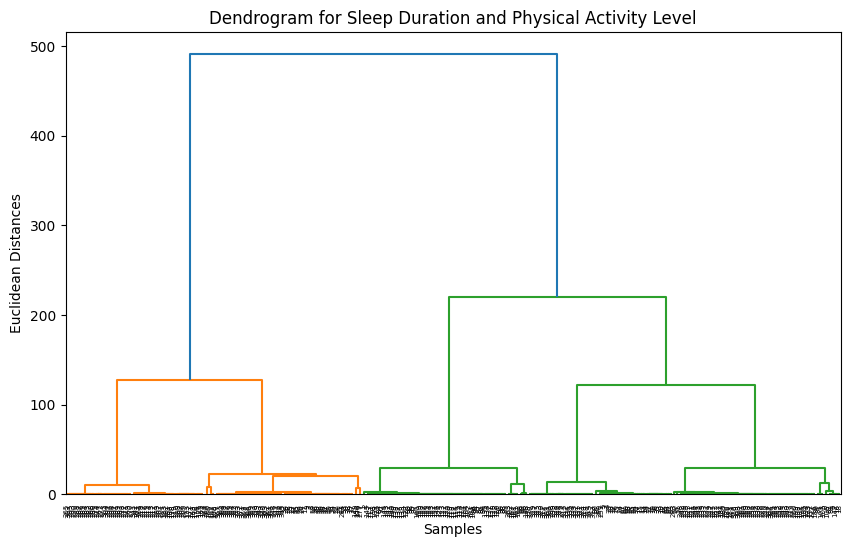

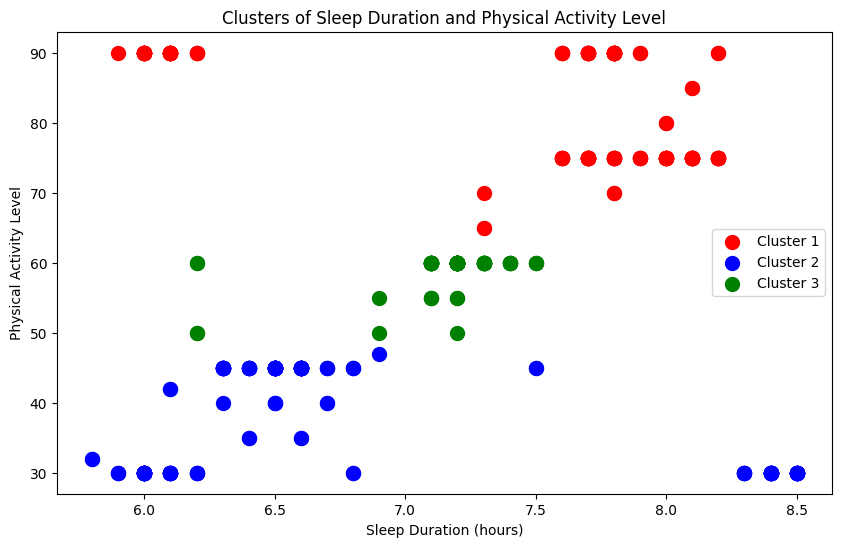

In [29]:
# Hierarchical clustering code:
# Step 1: Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering

# Step 2: Load the sleep dataset
data = pd.read_csv('sleep_health.csv')

# Step 3: Select features for clustering (Sleep Duration and Physical Activity Level)
X = data[['Sleep_Duration', 'Physical_Activity_Level']].values

# Step 4: Create and plot dendrogram to find optimal number of clusters
plt.figure(figsize=(10, 6))
dendrogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram for Sleep Duration and Physical Activity Level')
plt.xlabel('Samples')
plt.ylabel('Euclidean Distances')
plt.show()

# Step 5: Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
y_hc = hc.fit_predict(X)

# Step 6: Visualize the clusters
plt.figure(figsize=(10, 6))
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s=100, c='red', label='Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s=100, c='blue', label='Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s=100, c='green', label='Cluster 3')
plt.title('Clusters of Sleep Duration and Physical Activity Level')
plt.xlabel('Sleep Duration (hours)')
plt.ylabel('Physical Activity Level')
plt.legend()
plt.show()
